## IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

## LOAD DATASET

In [5]:
df = pd.read_csv("C:/Users/nikhi/OneDrive/Desktop/TECHOLAS/DataVinci_Assignment/Dataset/Ecommerce_Transactions_Data.csv")

## VIEW DATA

In [6]:
df.head()

,TransactionNo,Date,ProductNo,Product,Price,Quantity,CustomerNo,Country,Category
0,704274,2024-03-06,10010,LED String Lights,10.00,11,13673.0,Netherlands,Lighting & Ambience
1,439989,2024-12-27,10001,Vintage Clock,15.99,8,56712.0,Sweden,Decor Essentials
2,607445,2024-11-16,10008,Notebook Pack,7.50,23,45809.0,Canada,Office & Study
3,784100,2023-06-11,10001,Vintage Clock,15.99,29,98102.0,Switzerland,Decor Essentials
4,973030,2024-04-21,10003,Wooden Picture Frame,9.99,4,26596.0,Belgium,Decor Essentials


## DATASET INFORMATION

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  500000 non-null  object 
 1   Date           500000 non-null  object 
 2   ProductNo      500000 non-null  int64  
 3   Product        500000 non-null  object 
 4   Price          500000 non-null  float64
 5   Quantity       500000 non-null  int64  
 6   CustomerNo     495038 non-null  float64
 7   Country        500000 non-null  object 
 8   Category       500000 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 34.3+ MB


## SUMMARY STATISTICS

In [8]:
df.describe()

,ProductNo,Price,Quantity,CustomerNo
count,500000.000000,500000.000000,500000.000000,495038.000000
mean,10005.496916,14.779835,14.583058,55004.411205
std,2.872036,7.213341,10.137969,25998.016638
min,10001.000000,5.000000,-30.000000,10000.000000
25%,10003.000000,9.990000,7.000000,32447.000000
50%,10005.000000,14.000000,15.000000,55000.000000
75%,10008.000000,19.990000,23.000000,77548.000000
max,10010.000000,30.000000,30.000000,99999.000000


## DATA CLEANING

### CHECK MISSING VALUES

In [9]:
df.isnull().sum()

TransactionNo       0
Date                0
ProductNo           0
Product             0
Price               0
Quantity            0
CustomerNo       4962
Country             0
Category            0
dtype: int64

### Missing Value Percentage

In [10]:
missing_percent = (df.isnull().sum() / len(df))*100

print(missing_percent)

TransactionNo    0.0000
Date             0.0000
ProductNo        0.0000
Product          0.0000
Price            0.0000
Quantity         0.0000
CustomerNo       0.9924
Country          0.0000
Category         0.0000
dtype: float64


### Handle Missing Values

In [11]:
customer_df = df.dropna(subset=['CustomerNo'])

print("Original Shape:", df.shape)
print("Customer Analysis Shape:", customer_df.shape)

Original Shape: (500000, 9)
Customer Analysis Shape: (495038, 9)


### Check Duplicate Records

In [12]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


### Check Negative Quantity

In [13]:
df[df['Quantity'] <= 0].head()

,TransactionNo,Date,ProductNo,Product,Price,Quantity,CustomerNo,Country,Category
28,C966293,2023-10-30,10002,Ceramic Vase,22.50,-11,76649.0,Sweden,Home Accents
61,C721221,2023-12-23,10009,Wall Art Poster,14.00,-4,96112.0,Sweden,Office & Study
120,C868216,2024-02-26,10009,Wall Art Poster,14.00,-5,14212.0,Spain,Office & Study
122,C648170,2023-06-15,10001,Vintage Clock,15.99,-27,53452.0,Netherlands,Decor Essentials
172,C315797,2023-03-13,10007,Glass Bowl Set,30.00,-24,37254.0,France,Home Accents


### Remove Cancelled Transactions

In [14]:
df = df[df['Quantity'] > 0]

df = df[df['Price'] > 0]

### Create Revenue Column

In [15]:
df['Revenue'] = df['Price'] * df['Quantity']

In [16]:
df.head()

,TransactionNo,Date,ProductNo,Product,Price,Quantity,CustomerNo,Country,Category,Revenue
0,704274,2024-03-06,10010,LED String Lights,10.00,11,13673.0,Netherlands,Lighting & Ambience,110.00
1,439989,2024-12-27,10001,Vintage Clock,15.99,8,56712.0,Sweden,Decor Essentials,127.92
2,607445,2024-11-16,10008,Notebook Pack,7.50,23,45809.0,Canada,Office & Study,172.50
3,784100,2023-06-11,10001,Vintage Clock,15.99,29,98102.0,Switzerland,Decor Essentials,463.71
4,973030,2024-04-21,10003,Wooden Picture Frame,9.99,4,26596.0,Belgium,Decor Essentials,39.96


### Convert Date Column

In [17]:
df['Date'] = pd.to_datetime(df['Date'])

### Final Dataset Check

In [18]:
print(df.shape)

df.info()

(485005, 10)
<class 'pandas.core.frame.DataFrame'>
Index: 485005 entries, 0 to 499999
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  485005 non-null  object        
 1   Date           485005 non-null  datetime64[ns]
 2   ProductNo      485005 non-null  int64         
 3   Product        485005 non-null  object        
 4   Price          485005 non-null  float64       
 5   Quantity       485005 non-null  int64         
 6   CustomerNo     480188 non-null  float64       
 7   Country        485005 non-null  object        
 8   Category       485005 non-null  object        
 9   Revenue        485005 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 40.7+ MB


### Revenue Statistics

In [19]:
print("Total Revenue:")
print(df['Revenue'].sum())

print("\nAverage Revenue:")
print(df['Revenue'].mean())

Total Revenue:
111182278.29999998

Average Revenue:
229.23944763456043


## Distribution of Transaction Amounts

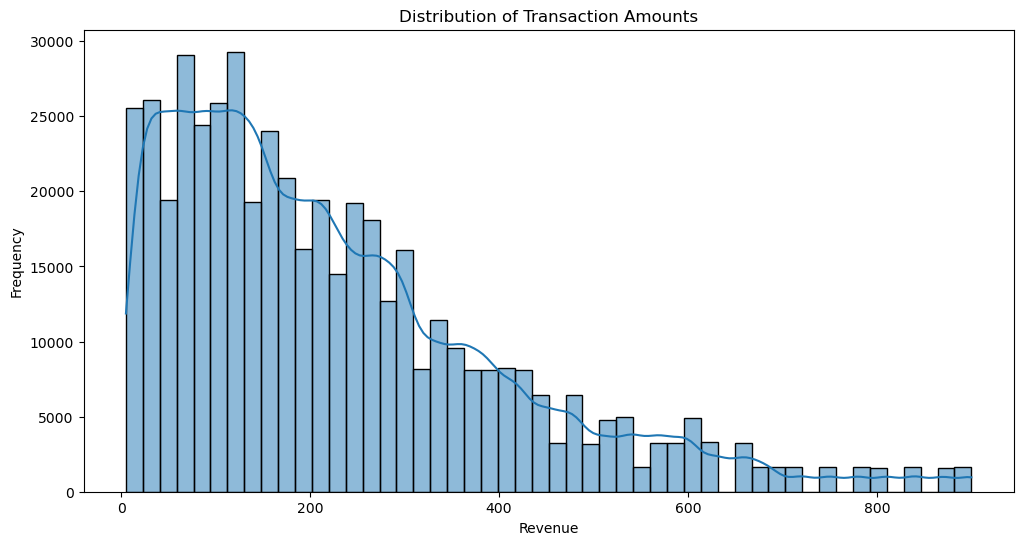

In [20]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['Revenue'],
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

In [21]:
plt.savefig("Q1_Distribution.png")

<Figure size 640x480 with 0 Axes>

### Box Plot

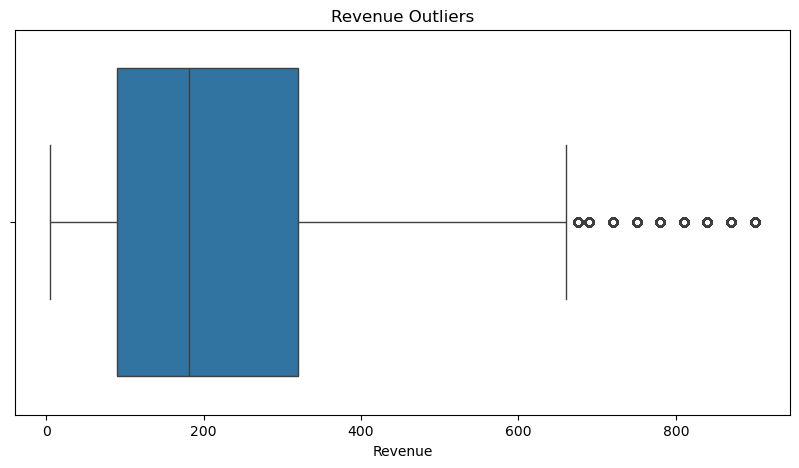

In [22]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['Revenue']
)

plt.title("Revenue Outliers")

plt.show()

### Interpretation

## Revenue Trend Over Time

In [23]:
daily_sales = (
    df.groupby('Date')['Revenue']
      .sum()
      .reset_index()
)

daily_sales.head()

,Date,Revenue
0,2023-01-01,166683.20
1,2023-01-02,147627.04
2,2023-01-03,164670.17
3,2023-01-04,156891.35
4,2023-01-05,154144.63


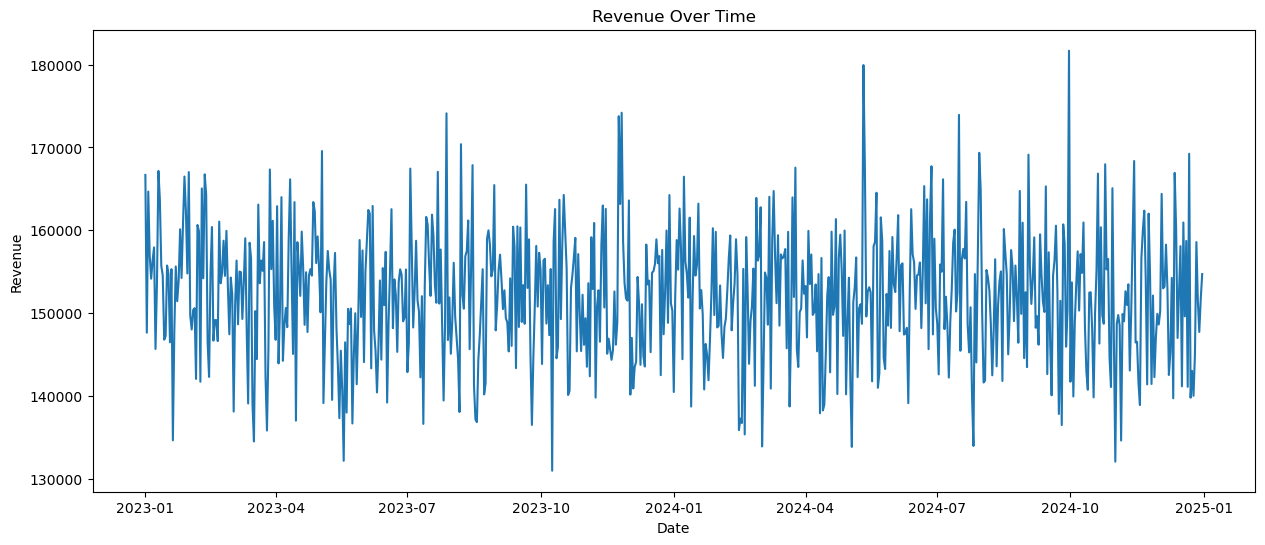

In [24]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales['Date'],
    daily_sales['Revenue']
)

plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

In [25]:
plt.savefig("Q2_Revenue_Trend.png")

<Figure size 640x480 with 0 Axes>

### Monthly Revenue

In [26]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = (
    df.groupby('Month')['Revenue']
      .sum()
)

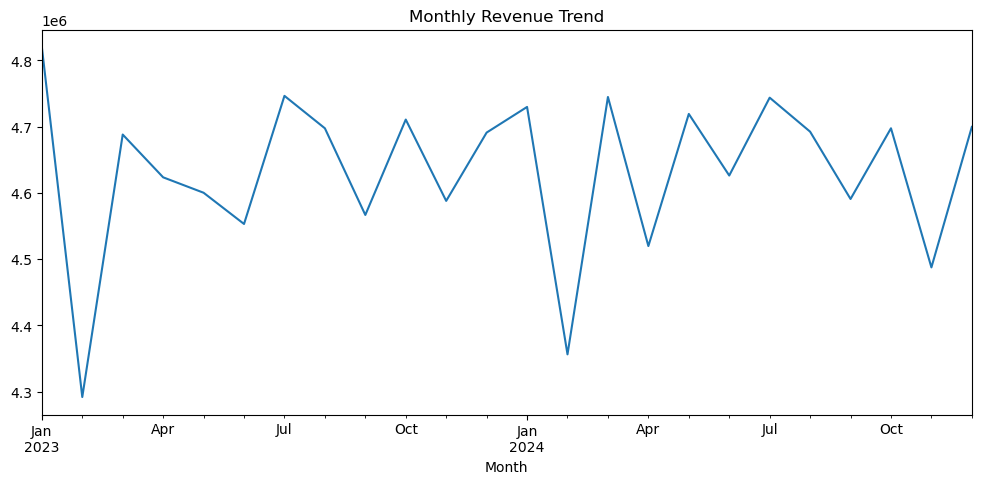

In [27]:
monthly_sales.plot(
    figsize=(12,5)
)

plt.title("Monthly Revenue Trend")

plt.show()

### Interpretation

### Revenue by Category

In [28]:
category_sales = (
    df.groupby('Category')['Revenue']
      .sum()
      .sort_values(
          ascending=False
      )
)

category_sales.head()

Category
Home Accents           39588390.00
Decor Essentials       19604808.48
Gifting & Occasions    18789881.07
Lighting & Ambience    17031009.75
Office & Study         16168189.00
Name: Revenue, dtype: float64

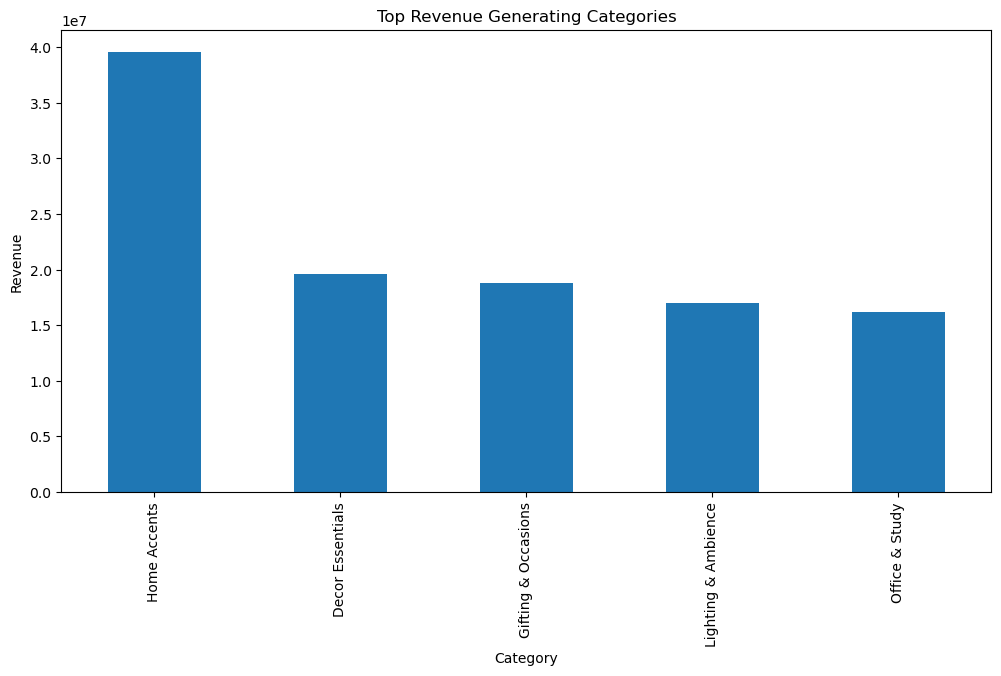

In [29]:
plt.figure(figsize=(12,6))

category_sales.head(10).plot(
    kind='bar'
)

plt.title(
    "Top Revenue Generating Categories"
)

plt.ylabel("Revenue")

plt.show()

In [30]:
plt.savefig("Q3_Category_Revenue.png")

<Figure size 640x480 with 0 Axes>

### Revenue Share

In [31]:
category_sales.head(10)

Category
Home Accents           39588390.00
Decor Essentials       19604808.48
Gifting & Occasions    18789881.07
Lighting & Ambience    17031009.75
Office & Study         16168189.00
Name: Revenue, dtype: float64

### Interpretation

## Customer Purchasing Behaviour

In [32]:
customer_df = customer_df[
    customer_df['Quantity'] > 0
]

customer_df = customer_df[
    customer_df['Price'] > 0
]

customer_df['Revenue'] = (
    customer_df['Price']
    *
    customer_df['Quantity']
)

customer_df['Date'] = pd.to_datetime(
    customer_df['Date']
)

In [33]:
customer_df['Month'] = (
    customer_df['Date']
      .dt.to_period('M')
)

In [34]:
monthly_customers = (
    customer_df.groupby('Month')
               ['CustomerNo']
               .nunique()
)

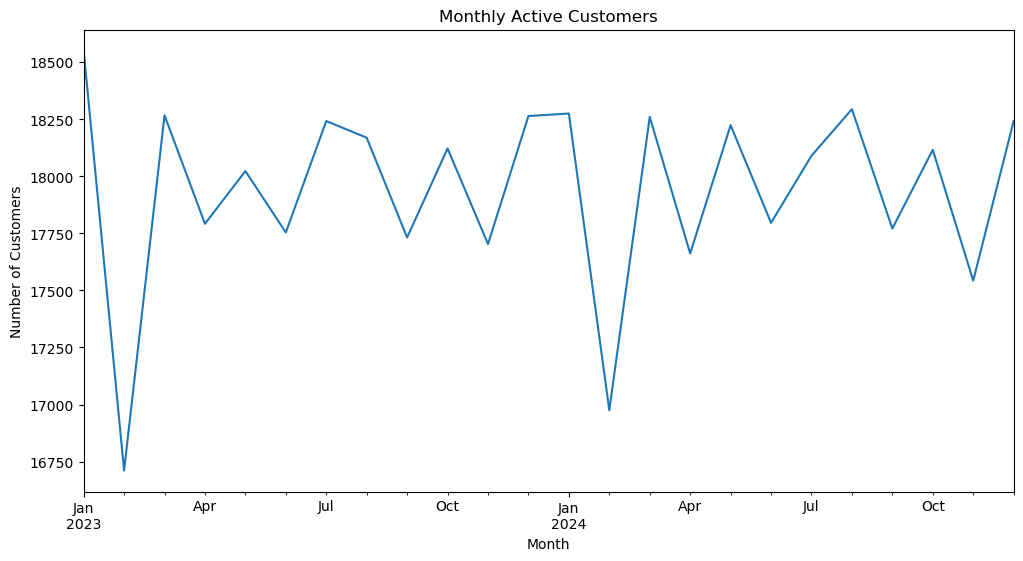

In [35]:
plt.figure(figsize=(12,6))

monthly_customers.plot()

plt.title(
    "Monthly Active Customers"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

In [36]:
plt.savefig("Q4_Monthly_Customers.png")

<Figure size 640x480 with 0 Axes>

### Top Customers

In [37]:
top_customers = (
    customer_df.groupby('CustomerNo')
               ['Revenue']
               .sum()
               .sort_values(
                   ascending=False
               )
               .head(10)
)

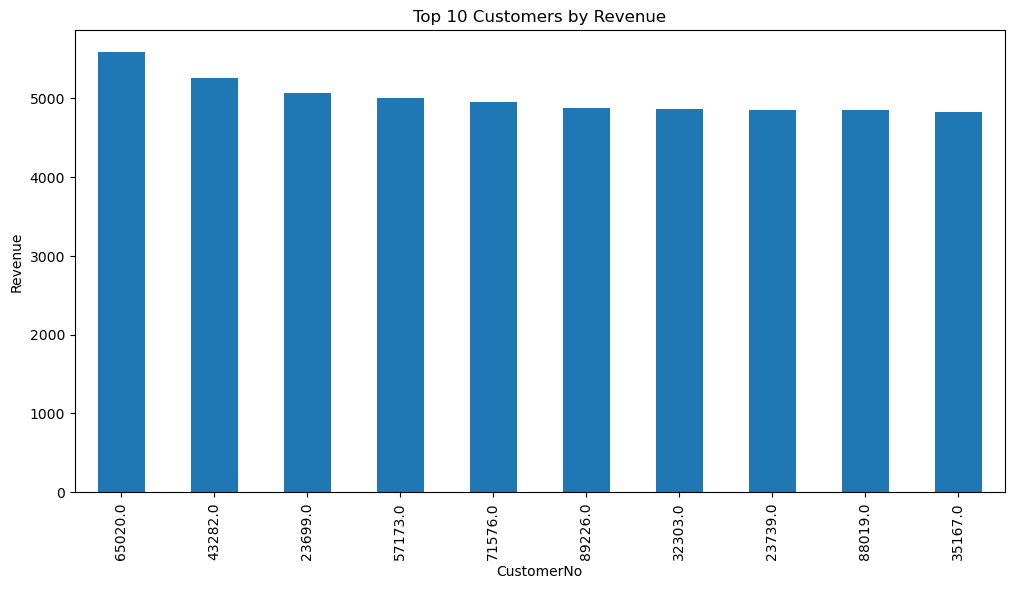

In [38]:
plt.figure(figsize=(12,6))

top_customers.plot(
    kind='bar'
)

plt.title(
    "Top 10 Customers by Revenue"
)

plt.ylabel("Revenue")

plt.show()

### Revenue by Country

In [39]:
country_sales = (
    df.groupby('Country')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales

Country
Sweden            9336551.00
Canada            9329903.53
Belgium           9309328.39
Germany           9301236.84
Australia         9289273.37
United Kingdom    9288452.14
Switzerland       9270519.10
Italy             9245507.65
Netherlands       9235451.49
USA               9227579.48
Name: Revenue, dtype: float64

### Plot Revenue by Country

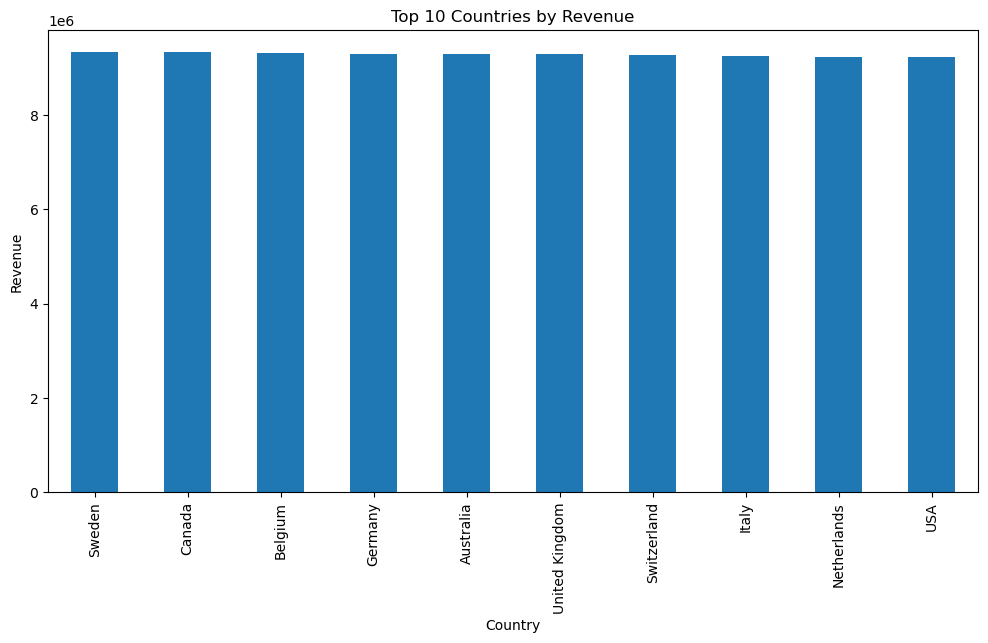

In [40]:
plt.figure(figsize=(12,6))

country_sales.plot(kind='bar')

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.show()

### Top Products

In [41]:
top_products = (
    df.groupby('Product')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Product
Glass Bowl Set          22661820.00
Ceramic Vase            16926570.00
Children's Toy Set      15020346.07
Vintage Clock           12116054.73
Wall Art Poster         10496794.00
Decorative Candle        9580209.75
Wooden Picture Frame     7488753.75
LED String Lights        7450800.00
Notebook Pack            5671395.00
Gift Card Pack           3769535.00
Name: Revenue, dtype: float64

### Plot Top Products

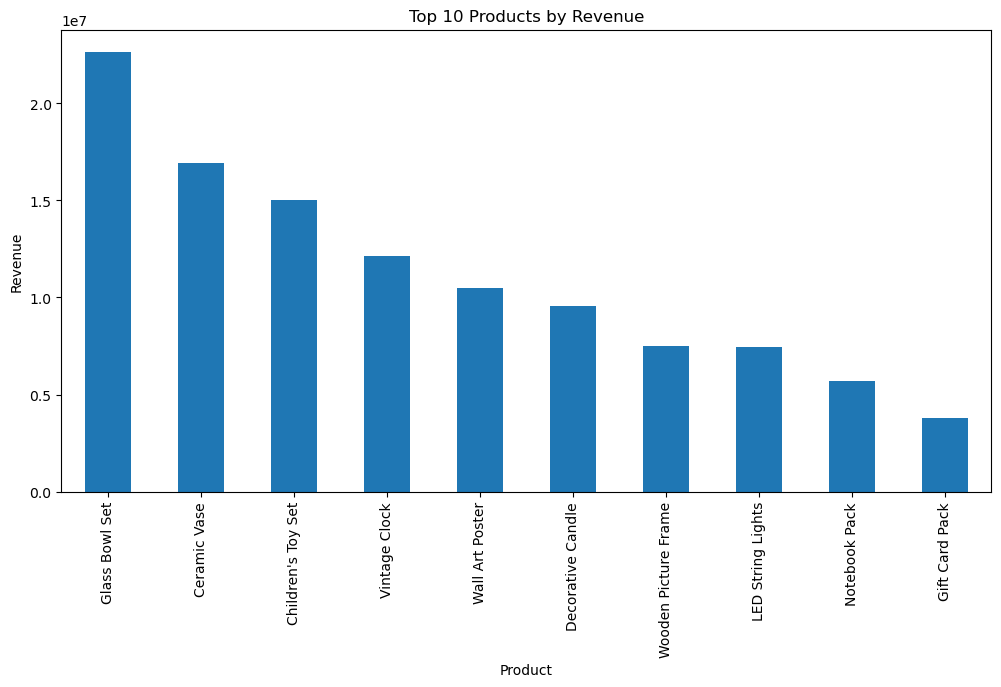

In [42]:
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

## Export Cleaned Dataset

In [43]:
df.to_csv(
    "cleaned_ecommerce_data.csv",
    index=False
)

print("Dataset exported successfully!")

Dataset exported successfully!


In [44]:
print(df.shape)

(485005, 11)


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 485005 entries, 0 to 499999
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  485005 non-null  object        
 1   Date           485005 non-null  datetime64[ns]
 2   ProductNo      485005 non-null  int64         
 3   Product        485005 non-null  object        
 4   Price          485005 non-null  float64       
 5   Quantity       485005 non-null  int64         
 6   CustomerNo     480188 non-null  float64       
 7   Country        485005 non-null  object        
 8   Category       485005 non-null  object        
 9   Revenue        485005 non-null  float64       
 10  Month          485005 non-null  period[M]     
dtypes: datetime64[ns](1), float64(3), int64(2), object(4), period[M](1)
memory usage: 44.4+ MB


In [46]:
df.head()

,TransactionNo,Date,ProductNo,Product,Price,Quantity,CustomerNo,Country,Category,Revenue,Month
0,704274,2024-03-06,10010,LED String Lights,10.00,11,13673.0,Netherlands,Lighting & Ambience,110.00,2024-03
1,439989,2024-12-27,10001,Vintage Clock,15.99,8,56712.0,Sweden,Decor Essentials,127.92,2024-12
2,607445,2024-11-16,10008,Notebook Pack,7.50,23,45809.0,Canada,Office & Study,172.50,2024-11
3,784100,2023-06-11,10001,Vintage Clock,15.99,29,98102.0,Switzerland,Decor Essentials,463.71,2023-06
4,973030,2024-04-21,10003,Wooden Picture Frame,9.99,4,26596.0,Belgium,Decor Essentials,39.96,2024-04
